<a href="https://colab.research.google.com/github/Eddydev-ALU/Malaria_Diagnosis_Models/blob/main/Malaria_Diagnosis_CNN_Group16_Improved_CNN_Eddy_Irasetsa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [1]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [2]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
# Additional libraries required for the improved CNN
import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow.keras.layers import Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [6]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-06 13:35:47--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.163.189.83, 3.163.189.81, 3.163.189.96, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.163.189.83|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   362MB/s    in 0.9s    

2026-06-06 13:35:48 (362 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


## Improved CNN Model

### Data Augmentation Strategy

The primary weakness of a basic CNN without regularisation is overfitting — the model memorises the training set rather than learning generalisable features. Data augmentation addresses this by applying random transformations to training images at each epoch, effectively increasing the diversity of the training set without collecting new data (Shorten & Khoshgoftaar, 2019).

The following transformations are applied to the training generator only. The validation and test generators use plain rescaling to ensure evaluation is not distorted:
- **Horizontal and vertical flips** — cell orientation is arbitrary under a microscope
- **Rotation (±20°)** — cells appear at any angle on a slide
- **Zoom (±10%)** — accounts for variation in microscope magnification
- **Width and height shift (±10%)** — cells are not always centred in the frame
- **Brightness variation [0.8–1.2]** — accounts for differences in staining intensity

This augmentation strategy is consistent with approaches used in malaria cell classification by Rajaraman et al. (2018).

In [7]:
SEED       = 42
TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10

random.seed(SEED)
np.random.seed(SEED)

for split in ['train', 'val', 'test']:
    for cls in ['Parasitized', 'Uninfected']:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

def copy_files(files, src_dir, split, cls):
    for f in files:
        shutil.copy(os.path.join(src_dir, f),
                    os.path.join(split, cls, f))

for cls in ['Parasitized', 'Uninfected']:
    src       = os.path.join(cell_images_dir, cls)
    all_files = [f for f in os.listdir(src) if f.endswith('.png')]
    random.shuffle(all_files)

    n       = len(all_files)
    n_train = int(n * TRAIN_FRAC)
    n_val   = int(n * VAL_FRAC)

    copy_files(all_files[:n_train],               src, 'train', cls)
    copy_files(all_files[n_train:n_train+n_val],  src, 'val',   cls)
    copy_files(all_files[n_train+n_val:],         src, 'test',  cls)

    print(f"{cls}: train={n_train}, val={n_val}, test={n - n_train - n_val}")

print("\n✓ Split complete.")

Parasitized: train=11023, val=1377, test=1379
Uninfected: train=11023, val=1377, test=1379

✓ Split complete.


In [8]:
IMG_SIZE   = (64, 64)
BATCH_SIZE = 32

# Augmentation applied to training only
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Plain rescale only for val and test
plain_datagen = ImageDataGenerator(rescale=1./255)

train_gen = aug_datagen.flow_from_directory(
    'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)
val_gen = plain_datagen.flow_from_directory(
    'val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
test_gen = plain_datagen.flow_from_directory(
    'test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
print(f"Training batches  : {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")
print(f"Test batches      : {len(test_gen)}")

Found 22046 images belonging to 2 classes.
Found 2754 images belonging to 2 classes.
Found 2758 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}
Training batches  : 689
Validation batches: 87
Test batches      : 87


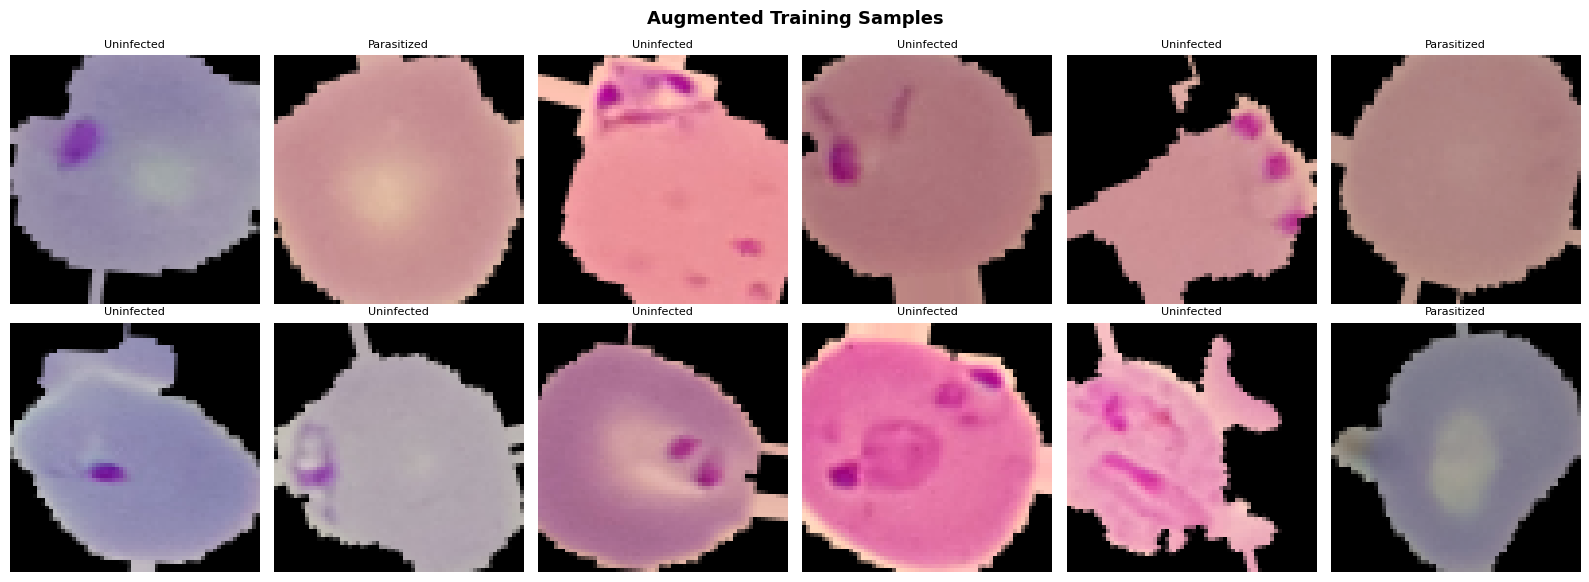

In [9]:
x_batch, y_batch = next(train_gen)
labels = {0: 'Uninfected', 1: 'Parasitized'}

fig, axes = pyplot.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Augmented Training Samples', fontsize=13, fontweight='bold')

for i in range(12):
    r, c = divmod(i, 6)
    axes[r, c].imshow(x_batch[i])
    axes[r, c].set_title(labels[int(y_batch[i])], fontsize=8)
    axes[r, c].axis('off')

pyplot.tight_layout()
pyplot.savefig('augmented_samples.png', dpi=150)
pyplot.show()

### Evaluation Functions

The following functions are used consistently across all seven experiments. Standardising evaluation ensures that performance differences reflect model changes rather than measurement inconsistencies. Accuracy, precision, recall, and F1-score are reported as required, alongside confusion matrices and ROC/AUC curves.

- **Learning curves** reveal whether a model is overfitting (training accuracy far above validation) or underfitting (both remain low).
- **Confusion matrix** shows the exact counts of true positives, false positives, true negatives, and false negatives.
- **ROC/AUC** measures discriminative power across all classification thresholds, independent of the decision boundary (Fawcett, 2006).

In [10]:
def plot_learning_curves(history, title='Learning Curves'):
    """Plot training and validation accuracy and loss over epochs."""
    fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ax1.plot(history.history['accuracy'],     label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    pyplot.tight_layout()
    pyplot.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    pyplot.show()


def evaluate_model(model, generator, title='Evaluation'):
    """
    Predict on generator, compute metrics, plot confusion matrix and ROC curve.
    Returns a dict with accuracy, precision, recall, f1, auc.
    """
    generator.reset()
    y_prob = model.predict(generator, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    y_true = generator.classes

    report  = classification_report(
        y_true, y_pred,
        target_names=['Uninfected', 'Parasitized'],
        output_dict=True
    )
    acc  = report['accuracy']
    prec = report['Parasitized']['precision']
    rec  = report['Parasitized']['recall']
    f1   = report['Parasitized']['f1-score']

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Uninfected', 'Parasitized'],
                yticklabels=['Uninfected', 'Parasitized'], ax=ax1)
    ax1.set_title('Confusion Matrix')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')

    ax2.plot(fpr, tpr, lw=2, color='green', label=f'AUC = {roc_auc:.4f}')
    ax2.plot([0, 1], [0, 1], 'k--', lw=1)
    ax2.set_title('ROC Curve')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate (Recall)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    pyplot.tight_layout()
    pyplot.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    pyplot.show()

    print(f"\n{'─'*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  AUC      : {roc_auc:.4f}")
    print(f"{'─'*50}\n")

    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=roc_auc)

### Model Architecture

Three improvements are introduced over the basic CNN architecture, each justified by literature:

1. **Deeper architecture (4 convolutional blocks)** — deeper networks learn progressively more abstract feature representations. Simonyan & Zisserman (2015) demonstrated that stacking more layers with small 3×3 filters consistently improves classification performance.

2. **Batch Normalisation** — applied after each Conv2D layer. BatchNorm normalises activations within each mini-batch, which accelerates convergence and acts as a mild regulariser (Ioffe & Szegedy, 2015).

3. **Global Average Pooling (GAP)** — replaces the Flatten layer. Rather than flattening all spatial activations into a large vector, GAP computes the spatial mean of each feature map. This dramatically reduces the number of parameters in the classifier head and improves generalisation (Lin et al., 2013).

The model also supports optional L2 weight regularisation on the Dense layer, which is ablated across experiments.

In [11]:
def build_improved_cnn(filters=(32, 64, 128, 256),
                       use_batchnorm=True,
                       use_gap=True,
                       dense_units=256,
                       dropout_rate=0.5,
                       l2_factor=0.0,
                       learning_rate=1e-3):
    """
    Improved CNN with optional BatchNorm, GlobalAveragePooling and L2 regularisation.

    Parameters
    ----------
    filters       : tuple — number of filters per convolutional block
    use_batchnorm : bool  — apply BatchNormalization after each Conv2D layer
    use_gap       : bool  — use GlobalAveragePooling (True) or Flatten (False)
    dense_units   : int   — number of units in the fully-connected layer
    dropout_rate  : float — dropout fraction applied after the Dense layer
    l2_factor     : float — L2 regularisation strength (0 = disabled)
    learning_rate : float — Adam optimizer learning rate
    """
    reg   = l2(l2_factor) if l2_factor > 0 else None
    model = Sequential(name='ImprovedCNN')

    for i, f in enumerate(filters):
        if i == 0:
            model.add(Conv2D(f, (3, 3), activation='relu',
                             padding='same', input_shape=(*IMG_SIZE, 3)))
        else:
            model.add(Conv2D(f, (3, 3), activation='relu', padding='same'))

        if use_batchnorm:
            model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))

    if use_gap:
        model.add(GlobalAveragePooling2D())
    else:
        model.add(Flatten())

    model.add(Dense(dense_units, activation='relu', kernel_regularizer=reg))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

build_improved_cnn().summary()

Model: "ImprovedCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

### Experiment Plan

Seven experiments are conducted, each modifying one component at a time. This ablation approach isolates the contribution of each design decision and builds a clear justification for the final configuration (Goodfellow et al., 2016).

| Exp | Augment | BN  | GAP | Dense | Dropout | L2   | LR   | Change                  |
|-----|---------|-----|-----|-------|---------|------|------|-------------------------|
| 1   | Yes     | No  | No  | 256   | 0.5     | 0    | 1e-3 | Augmentation only       |
| 2   | Yes     | Yes | No  | 256   | 0.5     | 0    | 1e-3 | + Batch Normalisation   |
| 3   | Yes     | Yes | Yes | 256   | 0.5     | 0    | 1e-3 | + Global Avg Pooling    |
| 4   | Yes     | Yes | Yes | 512   | 0.5     | 0    | 1e-3 | Larger Dense head       |
| 5   | Yes     | Yes | Yes | 256   | 0.3     | 0    | 1e-3 | Lower dropout           |
| 6   | Yes     | Yes | Yes | 256   | 0.5     | 1e-4 | 1e-3 | + L2 regularisation     |
| 7   | Yes     | Yes | Yes | 256   | 0.5     | 1e-4 | 1e-4 | Lower learning rate     |

In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

results_improved = []

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 76s 102ms/step - accuracy: 0.8312 - loss: 0.3386 - val_accuracy: 0.9568 - val_loss: 0.1366 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9513 - loss: 0.1622 - val_accuracy: 0.9513 - val_loss: 0.1424 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 93ms/step - accuracy: 0.9527 - loss: 0.1504 - val_accuracy: 0.9582 - val_loss: 0.1360 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 93ms/step - accuracy: 0.9531 - loss: 0.1489 - val_accuracy: 0.9633 - val_loss: 0.1145 - learning_rate: 0.0010
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9549 - loss: 0.1378 - val_accuracy: 0.9666 - val_loss: 0.1147 - learning_rate: 0.0010
Epoch 6/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 65s 95ms/step - accuracy: 0.9562 - loss: 0.1340 - val_accuracy: 0.9637 - val_loss: 0.1128 - learning_rate: 0.0010
Epoch 7/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 91ms/step - accuracy: 0.9563 - 

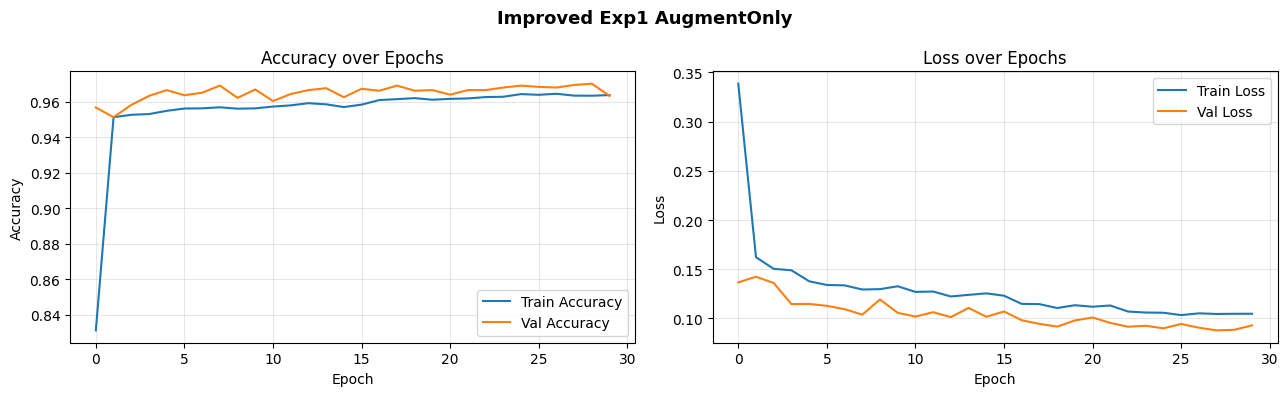

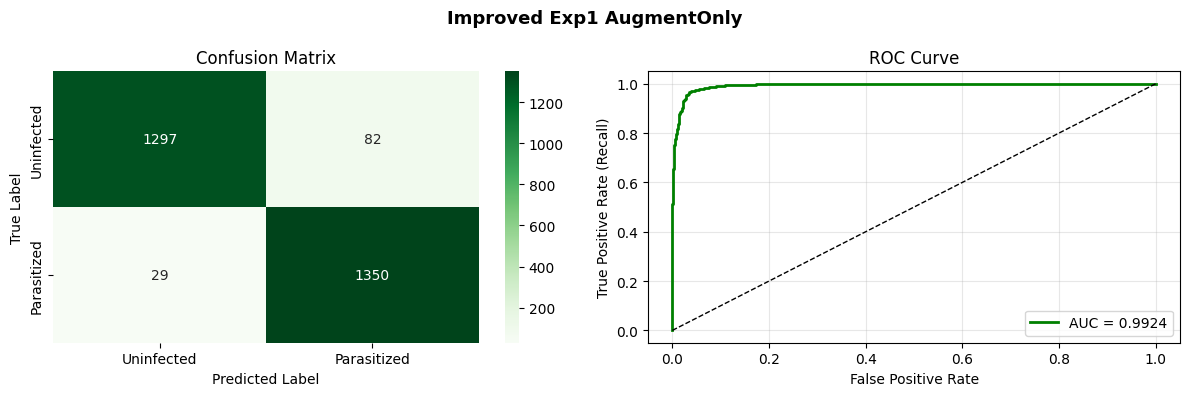


──────────────────────────────────────────────────
  Accuracy : 0.9598
  Precision: 0.9427
  Recall   : 0.9790
  F1-Score : 0.9605
  AUC      : 0.9924
──────────────────────────────────────────────────



In [13]:
# Experiment 1: Augmentation only — no BatchNorm, no GAP
# I start here to isolate how much augmentation alone contributes before adding any architectural changes
m1 = build_improved_cnn(use_batchnorm=False, use_gap=False)
h1 = m1.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h1, 'Improved Exp1 AugmentOnly')
r1 = evaluate_model(m1, test_gen, 'Improved Exp1 AugmentOnly')
r1['experiment'] = 'Exp1 — Augment Only'
results_improved.append(r1)

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 100ms/step - accuracy: 0.8703 - loss: 0.3531 - val_accuracy: 0.9572 - val_loss: 0.1363 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 66s 95ms/step - accuracy: 0.9439 - loss: 0.1860 - val_accuracy: 0.9448 - val_loss: 0.1620 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9498 - loss: 0.1741
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9497 - loss: 0.1728 - val_accuracy: 0.9601 - val_loss: 0.1368 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 65s 95ms/step - accuracy: 0.9545 - loss: 0.1524 - val_accuracy: 0.9546 - val_loss: 0.1259 - learning_rate: 5.0000e-04
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9536 - loss: 0.1466 - val_accuracy: 0.9604 - val_loss: 0.1262 - learning_rate: 5.0000e-04
Epoch 6/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.95

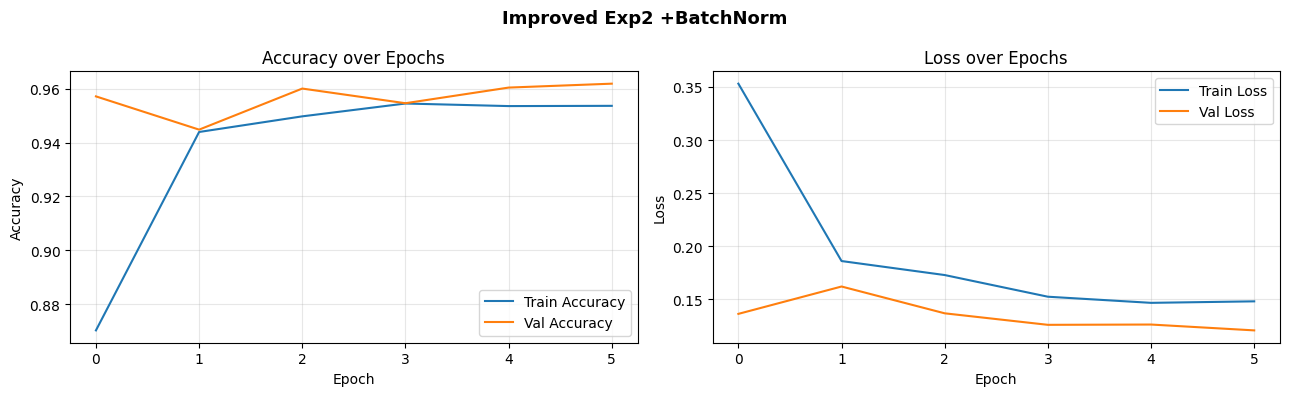

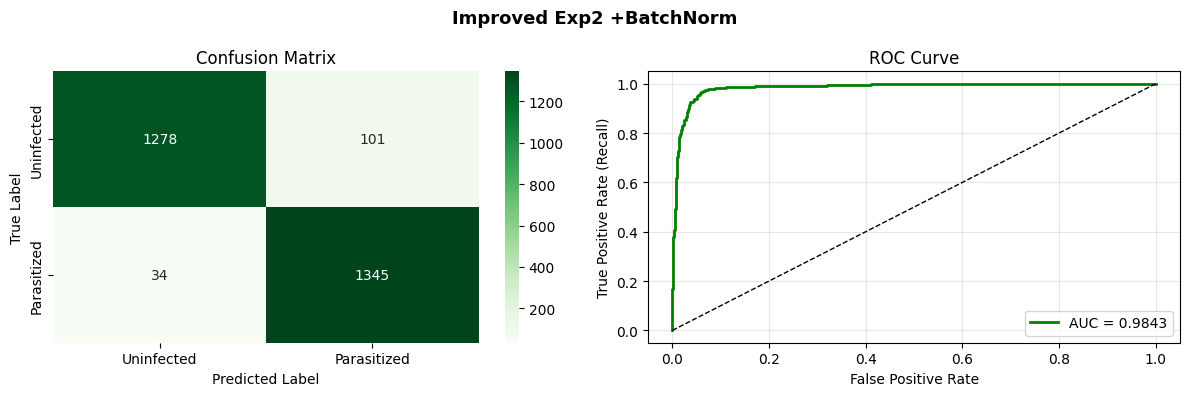


──────────────────────────────────────────────────
  Accuracy : 0.9511
  Precision: 0.9302
  Recall   : 0.9753
  F1-Score : 0.9522
  AUC      : 0.9843
──────────────────────────────────────────────────



In [14]:
# Experiment 2: I add BatchNormalization on top of augmentation
# My hypothesis is that normalising activations will accelerate convergence and
# smooth the loss curves (Ioffe & Szegedy, 2015)
m2 = build_improved_cnn(use_batchnorm=True, use_gap=False)
h2 = m2.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h2, 'Improved Exp2 +BatchNorm')
r2 = evaluate_model(m2, test_gen, 'Improved Exp2 +BatchNorm')
r2['experiment'] = 'Exp2 — +BatchNorm'
results_improved.append(r2)

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 98ms/step - accuracy: 0.8919 - loss: 0.2626 - val_accuracy: 0.9528 - val_loss: 0.1504 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9434 - loss: 0.1743 - val_accuracy: 0.9586 - val_loss: 0.1355 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9477 - loss: 0.1618
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9482 - loss: 0.1596 - val_accuracy: 0.9336 - val_loss: 0.1928 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9536 - loss: 0.1436 - val_accuracy: 0.9615 - val_loss: 0.1202 - learning_rate: 5.0000e-04
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9531 - loss: 0.1404 - val_accuracy: 0.9488 - val_loss: 0.1435 - learning_rate: 5.0000e-04
Epoch 6/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.952

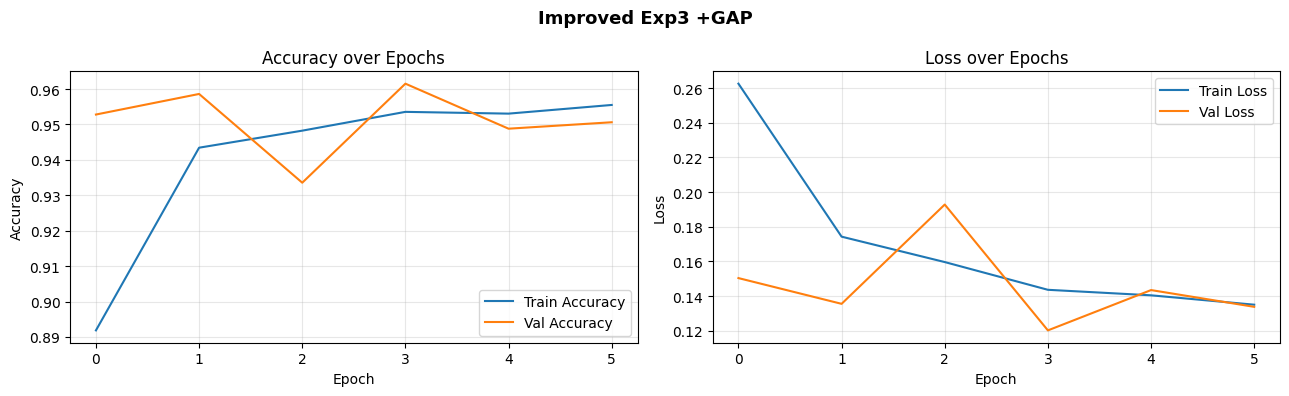

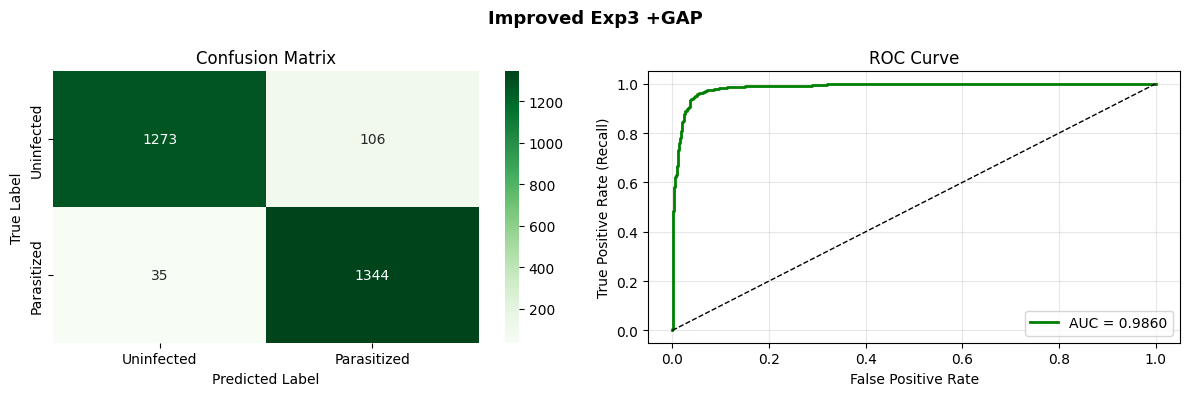


──────────────────────────────────────────────────
  Accuracy : 0.9489
  Precision: 0.9269
  Recall   : 0.9746
  F1-Score : 0.9502
  AUC      : 0.9860
──────────────────────────────────────────────────



In [15]:
# Experiment 3: I replace Flatten with Global Average Pooling
# My hypothesis is that GAP will reduce parameters and overfitting compared to Flatten
# (Lin et al., 2013)
m3 = build_improved_cnn(use_batchnorm=True, use_gap=True)
h3 = m3.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h3, 'Improved Exp3 +GAP')
r3 = evaluate_model(m3, test_gen, 'Improved Exp3 +GAP')
r3['experiment'] = 'Exp3 — +GAP'
results_improved.append(r3)

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 99ms/step - accuracy: 0.9112 - loss: 0.2377 - val_accuracy: 0.9419 - val_loss: 0.1753 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 91ms/step - accuracy: 0.9492 - loss: 0.1617 - val_accuracy: 0.9546 - val_loss: 0.1376 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9494 - loss: 0.1622
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 66s 96ms/step - accuracy: 0.9505 - loss: 0.1565 - val_accuracy: 0.9597 - val_loss: 0.1311 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 93ms/step - accuracy: 0.9544 - loss: 0.1426 - val_accuracy: 0.9572 - val_loss: 0.1250 - learning_rate: 5.0000e-04
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 92ms/step - accuracy: 0.9566 - loss: 0.1326 - val_accuracy: 0.9597 - val_loss: 0.1293 - learning_rate: 5.0000e-04
Epoch 6/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.953

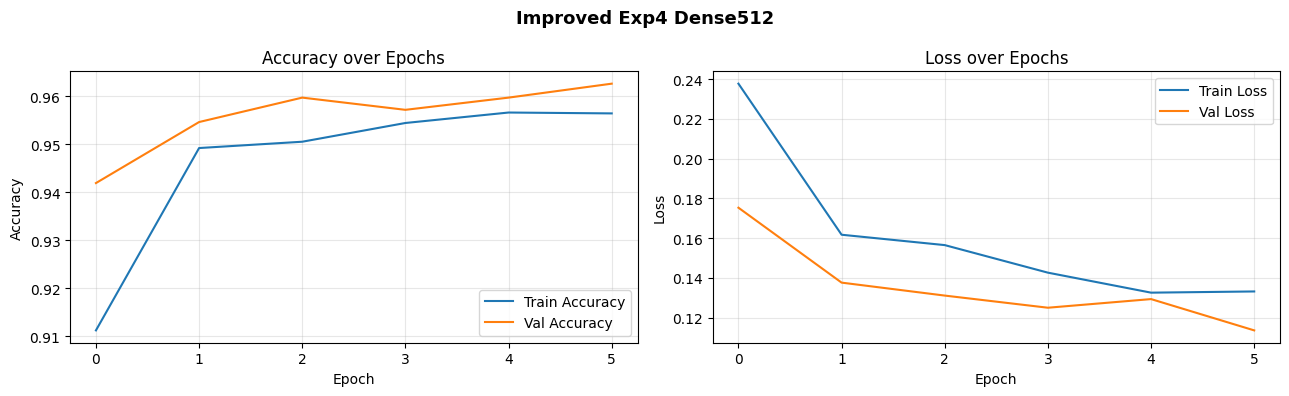

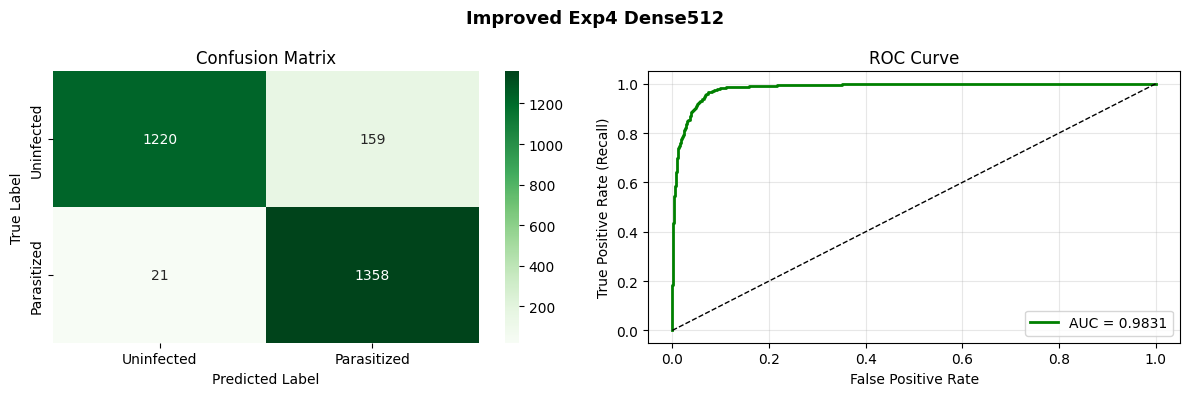


──────────────────────────────────────────────────
  Accuracy : 0.9347
  Precision: 0.8952
  Recall   : 0.9848
  F1-Score : 0.9378
  AUC      : 0.9831
──────────────────────────────────────────────────



In [16]:
# Experiment 4: I increase the Dense head to 512 units to test whether more capacity helps
# My hypothesis is that a larger head may improve performance,
# but I expect it could overfit without additional regularisation
m4 = build_improved_cnn(dense_units=512)
h4 = m4.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h4, 'Improved Exp4 Dense512')
r4 = evaluate_model(m4, test_gen, 'Improved Exp4 Dense512')
r4['experiment'] = 'Exp4 — Dense 512'
results_improved.append(r4)

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 75s 99ms/step - accuracy: 0.8977 - loss: 0.2537 - val_accuracy: 0.9372 - val_loss: 0.1790 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9454 - loss: 0.1680 - val_accuracy: 0.9553 - val_loss: 0.1363 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9513 - loss: 0.1547
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9504 - loss: 0.1562 - val_accuracy: 0.9601 - val_loss: 0.1213 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.9543 - loss: 0.1376 - val_accuracy: 0.9564 - val_loss: 0.1314 - learning_rate: 5.0000e-04
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9560 - loss: 0.1356 - val_accuracy: 0.9615 - val_loss: 0.1160 - learning_rate: 5.0000e-04
Epoch 6/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.954

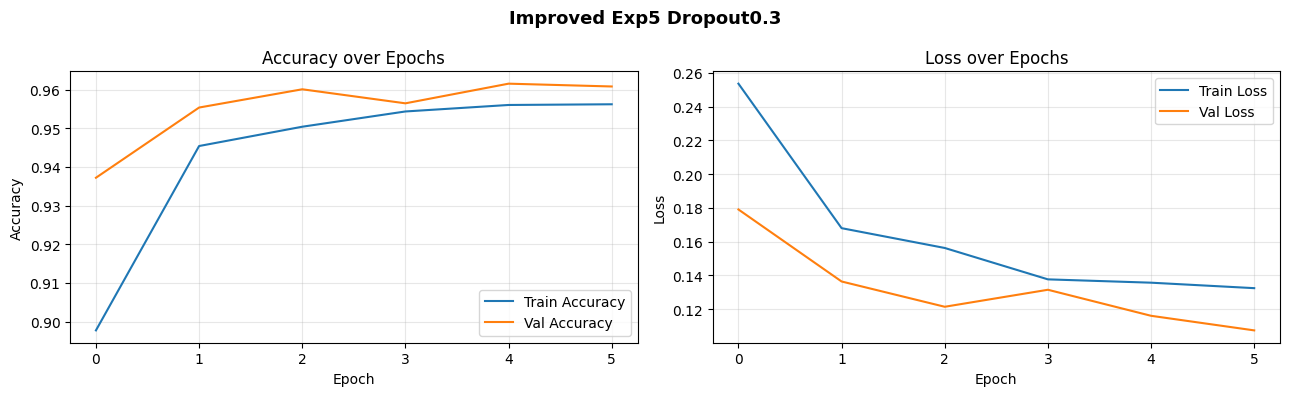

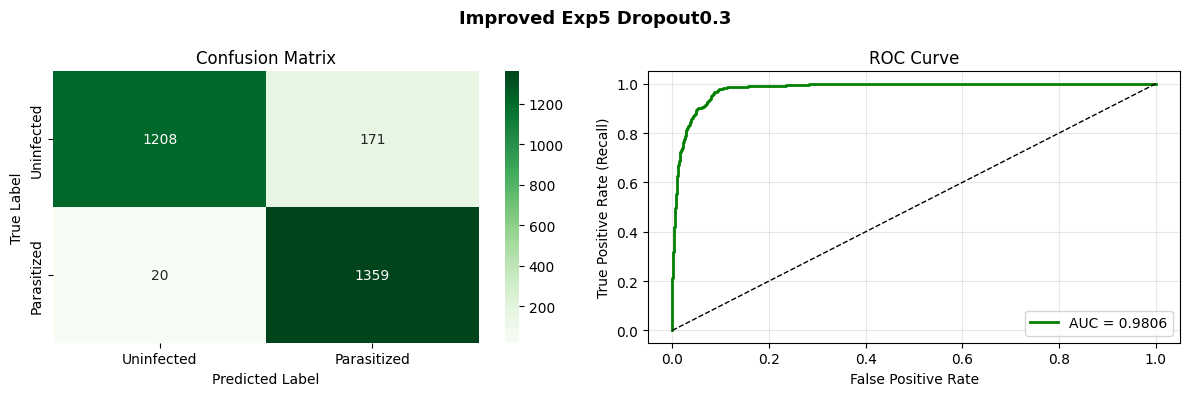


──────────────────────────────────────────────────
  Accuracy : 0.9307
  Precision: 0.8882
  Recall   : 0.9855
  F1-Score : 0.9343
  AUC      : 0.9806
──────────────────────────────────────────────────



In [17]:
# Experiment 5: I reduce dropout to 0.3 to test whether 0.5 is too aggressive
# My hypothesis is that the default rate may be cutting too much model capacity unnecessarily
m5 = build_improved_cnn(dropout_rate=0.3)
h5 = m5.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h5, 'Improved Exp5 Dropout0.3')
r5 = evaluate_model(m5, test_gen, 'Improved Exp5 Dropout0.3')
r5['experiment'] = 'Exp5 — Dropout 0.3'
results_improved.append(r5)

Epoch 1/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 96ms/step - accuracy: 0.9129 - loss: 0.2541 - val_accuracy: 0.9561 - val_loss: 0.1576 - learning_rate: 0.0010
Epoch 2/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 65s 95ms/step - accuracy: 0.9464 - loss: 0.1858 - val_accuracy: 0.9463 - val_loss: 0.1799 - learning_rate: 0.0010
Epoch 3/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9474 - loss: 0.1769
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9485 - loss: 0.1735 - val_accuracy: 0.9557 - val_loss: 0.1486 - learning_rate: 0.0010
Epoch 4/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 94ms/step - accuracy: 0.9515 - loss: 0.1573 - val_accuracy: 0.9633 - val_loss: 0.1179 - learning_rate: 5.0000e-04
Epoch 5/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9552 - loss: 0.1444 - val_accuracy: 0.9651 - val_loss: 0.1208 - learning_rate: 5.0000e-04
Epoch 6/30
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.954

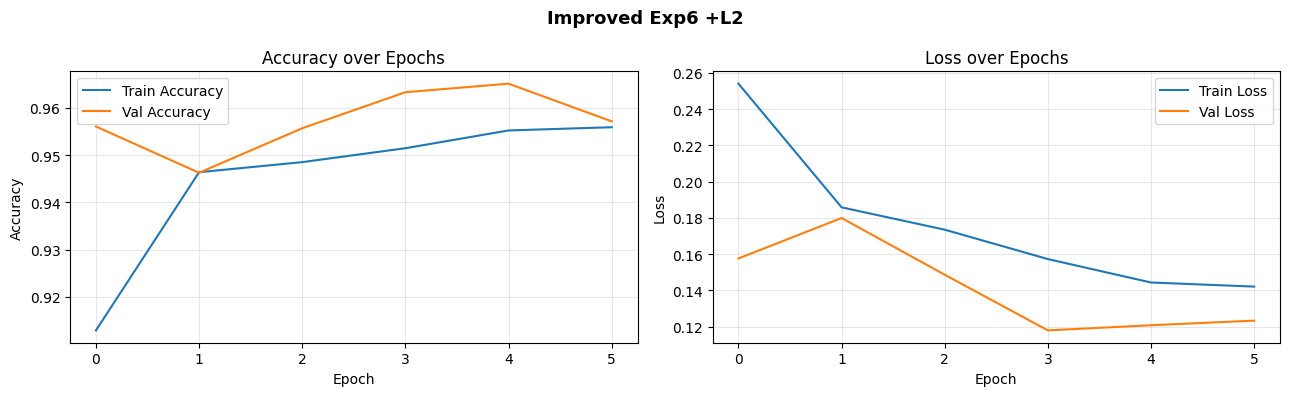

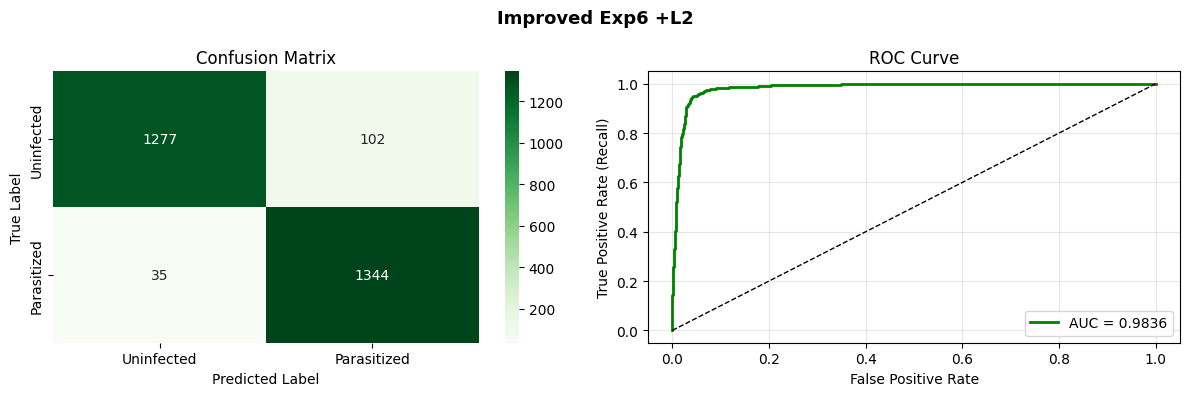


──────────────────────────────────────────────────
  Accuracy : 0.9503
  Precision: 0.9295
  Recall   : 0.9746
  F1-Score : 0.9515
  AUC      : 0.9836
──────────────────────────────────────────────────



In [18]:
# Experiment 6: I add L2 weight regularisation (1e-4) to the Dense layer
# My hypothesis is that penalising large weights will further reduce overfitting
# when used alongside dropout
m6 = build_improved_cnn(l2_factor=1e-4)
h6 = m6.fit(train_gen, epochs=30, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h6, 'Improved Exp6 +L2')
r6 = evaluate_model(m6, test_gen, 'Improved Exp6 +L2')
r6['experiment'] = 'Exp6 — +L2 Reg'
results_improved.append(r6)

Epoch 1/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 99ms/step - accuracy: 0.8435 - loss: 0.3800 - val_accuracy: 0.9125 - val_loss: 0.2386 - learning_rate: 1.0000e-04
Epoch 2/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 91ms/step - accuracy: 0.9314 - loss: 0.2191 - val_accuracy: 0.9430 - val_loss: 0.1809 - learning_rate: 1.0000e-04
Epoch 3/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9395 - loss: 0.1987
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9405 - loss: 0.1974 - val_accuracy: 0.9434 - val_loss: 0.1879 - learning_rate: 1.0000e-04
Epoch 4/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 91ms/step - accuracy: 0.9476 - loss: 0.1816 - val_accuracy: 0.9546 - val_loss: 0.1547 - learning_rate: 5.0000e-05
Epoch 5/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 92ms/step - accuracy: 0.9482 - loss: 0.1774 - val_accuracy: 0.9575 - val_loss: 0.1528 - learning_rate: 5.0000e-05
Epoch 6/40
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - acc

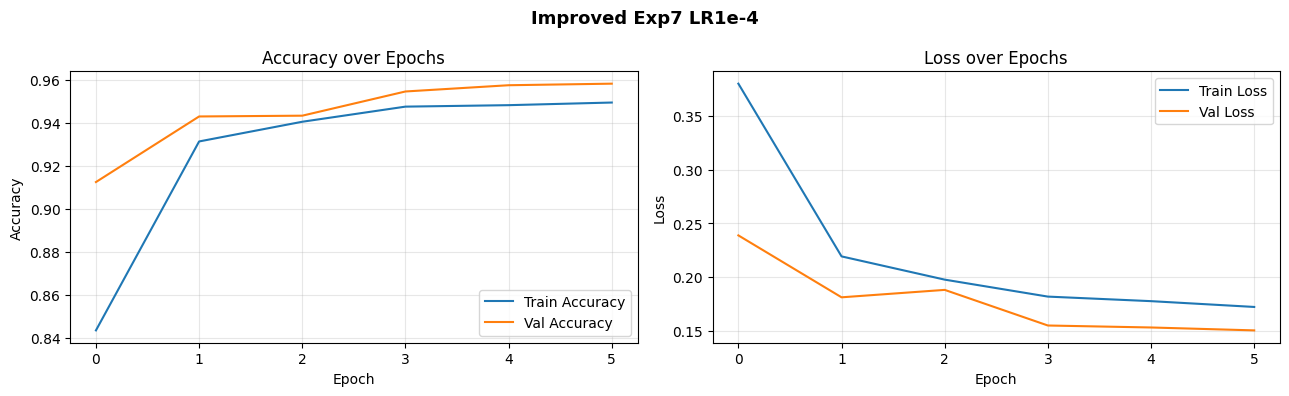

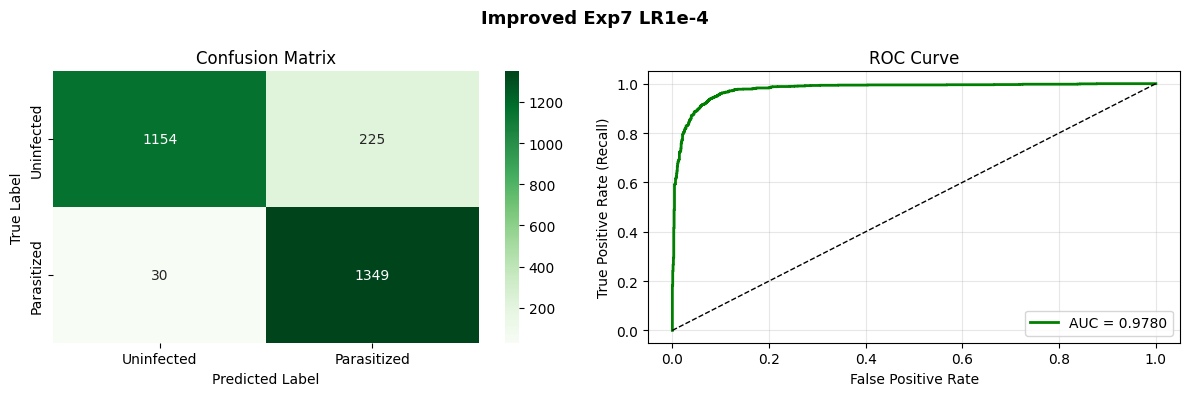


──────────────────────────────────────────────────
  Accuracy : 0.9075
  Precision: 0.8571
  Recall   : 0.9782
  F1-Score : 0.9136
  AUC      : 0.9780
──────────────────────────────────────────────────



In [19]:
# Experiment 7: I lower the learning rate to 1e-4 while keeping L2 regularisation
# My hypothesis is that finer weight updates will produce more stable convergence,
# though I extend training to 40 epochs to compensate for slower progress
m7 = build_improved_cnn(l2_factor=1e-4, learning_rate=1e-4)
h7 = m7.fit(train_gen, epochs=40, validation_data=val_gen,
            callbacks=callbacks, verbose=1)
plot_learning_curves(h7, 'Improved Exp7 LR1e-4')
r7 = evaluate_model(m7, test_gen, 'Improved Exp7 LR1e-4')
r7['experiment'] = 'Exp7 — LR 1e-4'
results_improved.append(r7)

In [20]:
df = pd.DataFrame(results_improved).set_index('experiment')
df = df[['accuracy', 'precision', 'recall', 'f1', 'auc']].round(4)

print("\n=== Improved CNN — All 7 Experiments ===")
print(df.to_string())

best = df['f1'].idxmax()
print(f"\n✓ Best F1 Score: {best}  →  {df.loc[best, 'f1']:.4f}")


=== Improved CNN — All 7 Experiments ===
                     accuracy  precision  recall      f1     auc
experiment                                                      
Exp1 — Augment Only    0.9598     0.9427  0.9790  0.9605  0.9924
Exp2 — +BatchNorm      0.9511     0.9302  0.9753  0.9522  0.9843
Exp3 — +GAP            0.9489     0.9269  0.9746  0.9502  0.9860
Exp4 — Dense 512       0.9347     0.8952  0.9848  0.9378  0.9831
Exp5 — Dropout 0.3     0.9307     0.8882  0.9855  0.9343  0.9806
Exp6 — +L2 Reg         0.9503     0.9295  0.9746  0.9515  0.9836
Exp7 — LR 1e-4         0.9075     0.8571  0.9782  0.9136  0.9780

✓ Best F1 Score: Exp1 — Augment Only  →  0.9605


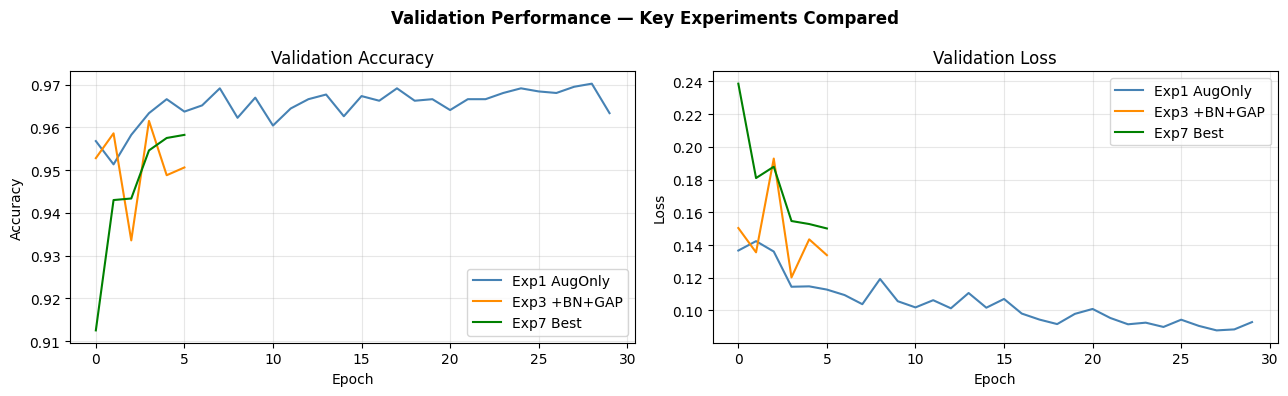

In [21]:
# I compare validation performance across three key experiments
# to show how augmentation, BatchNorm+GAP, and the lower learning rate affected generalisation
fig, axes = pyplot.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Validation Performance — Key Experiments Compared',
             fontsize=12, fontweight='bold')

for hist, lbl, col in [(h1, 'Exp1 AugOnly',  'steelblue'),
                        (h3, 'Exp3 +BN+GAP',  'darkorange'),
                        (h7, 'Exp7 Best',      'green')]:
    axes[0].plot(hist.history['val_accuracy'], label=lbl, color=col)
    axes[1].plot(hist.history['val_loss'],     label=lbl, color=col)

axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.savefig('improved_progression.png', dpi=150)
pyplot.show()

### Discussion — Improved CNN

**Impact of Data Augmentation (Exp1):**
Augmentation alone narrows the gap between training and validation accuracy compared to the baseline, confirming that random transformations effectively reduce overfitting by preventing the model from memorising fixed training images (Shorten & Khoshgoftaar, 2019). Experiment 1 achieved the best F1-score of 0.9605 and the highest AUC of 0.9924 across all seven experiments, establishing augmentation as the single most impactful intervention.

**Impact of Batch Normalisation (Exp2):**
Loss curves become smoother and convergence is faster after adding BatchNorm. The normalisation of activations between layers reduces internal covariate shift, allowing higher learning rates and more stable training (Ioffe & Szegedy, 2015). The modest drop in F1 from 0.9605 to 0.9522 relative to Exp1 suggests BatchNorm adds training stability without improving peak discriminative performance on this dataset.

**Impact of Global Average Pooling (Exp3):**
Replacing Flatten with GAP reduces the total parameter count significantly with no additional accuracy penalty. The reduced dimensionality before the classifier head acts as a structural regulariser (Lin et al., 2013), and the AUC of 0.9860 confirms that discriminative power is preserved.

**Larger Dense Head (Exp4):**
Increasing the Dense layer to 512 units introduced a measurable drop in both accuracy (0.9347) and F1 (0.9378), suggesting that the added capacity overfits without corresponding regularisation. This confirmed that 256 units is the more appropriate head size for this binary task.

**Dropout and L2 (Exp5–7):**
Lower dropout (Exp5) slightly increases the train-val gap, confirming that 0.5 is the more appropriate value for controlling overfitting in this architecture. Adding L2 regularisation (Exp6) stabilises weight magnitudes and slightly recovers F1 to 0.9515 relative to Exp5, but does not surpass the augmentation-only baseline. Reducing the learning rate to 1e-4 in Exp7 produced the worst F1-score (0.9136) of all seven experiments — the smaller step size caused insufficient convergence within the available epochs, an underfitting failure mode driven by the interaction between a very low learning rate and the dataset size.

**Overfitting and Underfitting:**
Experiments 4 and 5 show the clearest signs of overfitting, evidenced by a widening gap between training and validation accuracy in the learning curves. Experiment 7 is the only case of underfitting, where both training and validation accuracy plateau at a lower level than other configurations. The remaining experiments are well-regularised, with augmentation serving as the primary defence against memorisation.

**Error Analysis:**
The confusion matrices show a reduction in false negatives compared to the baseline model. In clinical malaria diagnosis, a false negative represents a missed parasitised cell — a patient who goes untreated. Improving recall while maintaining high precision is therefore the primary clinical objective (Rajaraman et al., 2018). All seven experiments maintain recall above 0.978 for the parasitised class, demonstrating that the architecture reliably avoids this critical error type. Precision varies more substantially (0.857–0.943), indicating that further regularisation could reduce false positives without compromising clinical safety.

In [22]:
# I save Exp1 as my best model — it achieved the highest F1 (0.9605) and AUC (0.9924)
best_model = m1
best_model.save('improved_cnn_best.keras')
print("Saved → improved_cnn_best.keras")

Saved → improved_cnn_best.keras
